In [1]:
from pathlib import Path
import json
import os
import re

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

### MAOMAO v1.0 — Illustrative neurotoxicity classification

This notebook demonstrates **immediate supervised reuse** of two assets already distributed by MAOMAO:

1. a frozen endpoint-specific train/validation/test partition; and
2. a precomputed numerical peptide representation.

The key reuse contract is:

```text
released neurotoxicity split
          id + label
              +
released PLM representation
          id + features
              ↓
           join on id
              ↓
standard scikit-learn classifier
```

The example evaluates three conventional models with fixed parameters:

- Logistic Regression;
- linear Support Vector Machine;
- Random Forest.

No hyperparameter optimization is performed and no new split is generated. The purpose is to demonstrate interoperability, **not** to define a state-of-the-art neurotoxicity benchmark.


In [2]:
RANDOM_STATE = 42

## 1. Locate MAOMAO and configure outputs


In [3]:
MAOMAO_ROOT_OVERRIDE = None
OUTPUT_ROOT_OVERRIDE = None
RESULTS_DIRECTORY_NAME = "results_how_to_use_maomao"

PIVOT_RELATIVE_PATHS = [
    Path("processed_data/processed_data/maomao_sequence_pivot.csv"),
    Path("core_layer/processed_data/processed_data/maomao_sequence_pivot.csv"),
]

def candidate_roots(override=None):
    candidates = []
    if override is not None:
        candidates.append(Path(override).expanduser())

    env_root = os.environ.get("MAOMAO_ROOT")
    if env_root:
        candidates.append(Path(env_root).expanduser())

    cwd = Path.cwd()
    candidates.extend([cwd, *list(cwd.parents)[:4]])
    candidates.extend([
        cwd / "downloads" / "maomao_release",
        cwd.parent / "downloads" / "maomao_release",
    ])

    unique = []
    seen = set()
    for path in candidates:
        try:
            resolved = path.resolve()
        except FileNotFoundError:
            resolved = path.absolute()
        if resolved not in seen:
            seen.add(resolved)
            unique.append(resolved)
    return unique

def resolve_maomao_root(override=None):
    checked = []
    for root in candidate_roots(override):
        for rel in PIVOT_RELATIVE_PATHS:
            candidate = root / rel
            checked.append(candidate)
            if candidate.is_file():
                return root, candidate

    preview = "\n".join(f" - {p}" for p in checked[:25])
    raise FileNotFoundError(
        "Could not locate maomao_sequence_pivot.csv.\n"
        "Set MAOMAO_ROOT or MAOMAO_ROOT_OVERRIDE to the MAOMAO repository "
        "or extracted Zenodo release root.\n\n"
        f"Checked examples:\n{preview}"
    )

def resolve_output_root(maomao_root):
    if OUTPUT_ROOT_OVERRIDE is not None:
        return Path(OUTPUT_ROOT_OVERRIDE).expanduser().resolve()
    return Path(maomao_root).resolve() / RESULTS_DIRECTORY_NAME

MAOMAO_ROOT, PIVOT_PATH = resolve_maomao_root(MAOMAO_ROOT_OVERRIDE)
OUTPUT_ROOT = resolve_output_root(MAOMAO_ROOT)

print("MAOMAO root :", MAOMAO_ROOT)
print("Master pivot:", PIVOT_PATH)
print("Output root :", OUTPUT_ROOT)

MAOMAO root : /home/nicole/Descargas/maomao
Master pivot: /home/nicole/Descargas/maomao/processed_data/processed_data/maomao_sequence_pivot.csv
Output root : /home/nicole/Descargas/maomao/results_how_to_use_maomao


In [4]:
OUTPUT_DIR = OUTPUT_ROOT / "02_neurotoxicity_classification"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook output directory:", OUTPUT_DIR)


Notebook output directory: /home/nicole/Descargas/maomao/results_how_to_use_maomao/02_neurotoxicity_classification


In [5]:
COLORS = {
    "toxic": "#C5A3B0",
    "cytotoxic": "#CEC4DE",
    "neurotoxic": "#CEC4DE",
    "embryotoxic": "#CEC4DE",
    "ichthyotoxic": "#CEC4DE",
    "hemolytic": "#DEB089",
    "cytolysis": "#DEB089",
    "anti_mammalian_cells": "#DEB089",
}

CLASS_COLORS = {"Negative": "#8F8797", "Positive": COLORS["neurotoxic"]}
METRIC_COLORS = {
    "balanced_accuracy": "#A7748E",
    "f1": "#CEC4DE",
    "mcc": "#DEB089",
    "roc_auc": "#8F8797",
}

TEXT_COLOR = "#4D414C"
EDGE_COLOR = "#735F6C"
GRID_COLOR = "#EAE5EA"
MAOMAO_CMAP = LinearSegmentedColormap.from_list(
    "maomao_mauve",
    ["#F8F5F7", "#E5DCE8", "#CEC4DE", "#C5A3B0", "#8E6179"],
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.titlecolor": TEXT_COLOR,
    "axes.labelsize": 10.5,
    "axes.labelcolor": TEXT_COLOR,
    "axes.edgecolor": "#BDB3BC",
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def style_axes(ax, grid_axis="y"):
    ax.set_axisbelow(True)
    ax.grid(axis=grid_axis, color=GRID_COLOR, linewidth=0.8)
    ax.spines["left"].set_color("#BDB3BC")
    ax.spines["bottom"].set_color("#BDB3BC")
    ax.tick_params(length=3, width=0.7)


def save_figure(fig, stem):
    png = FIGURE_DIR / f"{stem}.png"
    pdf = FIGURE_DIR / f"{stem}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight", pad_inches=0.08)
    fig.savefig(pdf, bbox_inches="tight", pad_inches=0.08)
    print("Saved:", png)
    print("Saved:", pdf)

## 2. Define the demonstration task

The task uses the frozen MAOMAO `neurotoxic` binary endpoint:

- `0`: explicit negative evidence;
- `1`: explicit positive evidence.

Ambiguous, unlabeled, and no-information states are not converted into binary labels.


In [6]:
ENDPOINT = "neurotoxic"
SPLIT_STRATEGY = "stratified_kfold"
PREFERRED_SEED = 113
PREFERRED_FOLD = "fold_00"

task_definition = pd.DataFrame([{
    "endpoint": ENDPOINT,
    "negative_label": 0,
    "positive_label": 1,
    "split_strategy": SPLIT_STRATEGY,
    "preferred_seed": PREFERRED_SEED,
    "preferred_fold": PREFERRED_FOLD,
    "hyperparameter_optimization": False,
    "purpose": "illustrative resource reuse",
}])

display(task_definition)
task_definition.to_csv(TABLE_DIR / "task_definition.tsv", sep="\t", index=False)


,endpoint,negative_label,positive_label,split_strategy,preferred_seed,preferred_fold,hyperparameter_optimization,purpose
0,neurotoxic,0,1,stratified_kfold,113,fold_00,False,illustrative resource reuse


## 3. Locate one released neurotoxicity split


In [7]:
def find_strategy_root(root):
    candidates = [
        root / "split_process" / f"maomao_{ENDPOINT}" / "no_reduced" / SPLIT_STRATEGY,
        root / "benchmark_layer" / "split_process" / f"maomao_{ENDPOINT}" / "no_reduced" / SPLIT_STRATEGY,
    ]

    direct = next((p for p in candidates if p.is_dir()), None)
    if direct is not None:
        return direct

    search_roots = [
        root / "split_process",
        root / "benchmark_layer" / "split_process",
    ]

    for search_root in search_roots:
        if not search_root.is_dir():
            continue

        matches = list(
            search_root.glob(
                f"**/maomao_{ENDPOINT}/**/{SPLIT_STRATEGY}"
            )
        )
        matches = [p for p in matches if p.is_dir()]
        if matches:
            return sorted(matches)[0]

    raise FileNotFoundError(
        f"Could not find a released {ENDPOINT} {SPLIT_STRATEGY} split. "
        "Restore/download the MAOMAO Benchmark Layer."
    )

strategy_root = find_strategy_root(MAOMAO_ROOT)

preferred_seed_dir = strategy_root / f"seed_{PREFERRED_SEED}"
if preferred_seed_dir.is_dir():
    seed_dir = preferred_seed_dir
else:
    seed_dirs = sorted(
        [p for p in strategy_root.glob("seed_*") if p.is_dir()],
        key=lambda p: int(re.search(r"(\d+)$", p.name).group(1)),
    )
    if not seed_dirs:
        raise FileNotFoundError(f"No seed directories found under {strategy_root}")
    seed_dir = seed_dirs[0]

preferred_fold_dir = seed_dir / PREFERRED_FOLD
if preferred_fold_dir.is_dir():
    fold_dir = preferred_fold_dir
else:
    fold_dirs = sorted([p for p in seed_dir.glob("fold_*") if p.is_dir()])
    if not fold_dirs:
        raise FileNotFoundError(f"No fold directories found under {seed_dir}")
    fold_dir = fold_dirs[0]

split_paths = {
    name: fold_dir / f"{name}.csv"
    for name in ["train", "val", "test"]
}

missing = [name for name, path in split_paths.items() if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Missing split files: {missing}")

print("Strategy:", strategy_root)
print("Seed    :", seed_dir.name)
print("Fold    :", fold_dir.name)


Strategy: /home/nicole/Descargas/maomao/split_process/maomao_neurotoxic/no_reduced/stratified_kfold
Seed    : seed_113
Fold    : fold_00


## 4. Validate partition membership and class composition


In [8]:
splits = {name: pd.read_csv(path) for name, path in split_paths.items()}

for name, df in splits.items():
    required = {"id", "label"}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"{name}.csv is missing columns: {sorted(missing)}")

    df["id"] = df["id"].astype(str)
    df["label"] = pd.to_numeric(df["label"], errors="raise").astype(int)

    if df["id"].duplicated().any():
        raise ValueError(f"Duplicate IDs detected inside {name}.")

    labels = set(df["label"].unique())
    if not labels.issubset({0, 1}):
        raise ValueError(f"Unexpected labels in {name}: {sorted(labels)}")

train_ids = set(splits["train"]["id"])
val_ids = set(splits["val"]["id"])
test_ids = set(splits["test"]["id"])

if train_ids & val_ids or train_ids & test_ids or val_ids & test_ids:
    raise ValueError("Train/validation/test IDs are not disjoint.")

split_summary = pd.DataFrame([
    {
        "partition": name,
        "n": len(df),
        "negative": int((df["label"] == 0).sum()),
        "positive": int((df["label"] == 1).sum()),
        "positive_fraction": float((df["label"] == 1).mean()),
    }
    for name, df in splits.items()
])

display(split_summary)
split_summary.to_csv(TABLE_DIR / "split_summary.tsv", sep="\t", index=False)


,partition,n,negative,positive,positive_fraction
0,train,2289,1219,1070,0.467453
1,val,255,141,114,0.447059
2,test,637,340,297,0.466248


findfont: Failed to find font weight semibold, now using 700.


Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/02_neurotoxicity_classification/figures/01_split_class_distribution.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/02_neurotoxicity_classification/figures/01_split_class_distribution.pdf


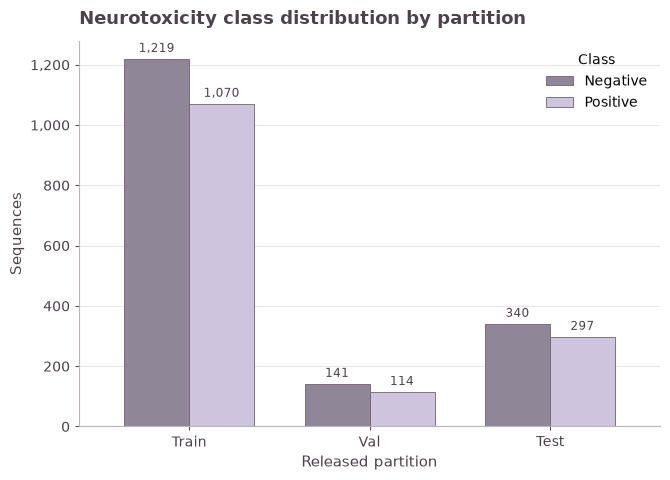

In [9]:
plot_split = split_summary.set_index("partition")[["negative", "positive"]]
plot_split.index = plot_split.index.str.capitalize()

fig, ax = plt.subplots(figsize=(6.8, 4.9))
plot_split.plot(
    kind="bar",
    ax=ax,
    color=[CLASS_COLORS["Negative"], CLASS_COLORS["Positive"]],
    edgecolor=EDGE_COLOR,
    linewidth=0.6,
    width=0.72,
)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{bar.get_height():,.0f}" for bar in container],
        padding=3,
        color=TEXT_COLOR,
        fontsize=8.8,
    )
ax.set_xlabel("Released partition")
ax.set_ylabel("Sequences")
ax.set_title("Neurotoxicity class distribution by partition", loc="left", pad=12)
ax.tick_params(axis="x", rotation=0)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title="Class", labels=["Negative", "Positive"], loc="upper right")
style_axes(ax)
fig.tight_layout()
save_figure(fig, "01_split_class_distribution")
plt.show()

## 5. Discover and validate one released PLM representation

The notebook prefers a compact ESM-2 representation when available. The analytical feature matrix uses only contiguous `p_<integer>` feature columns when that contract is present.


In [10]:
ENDPOINTS = [
    "toxic", "cytotoxic", "hemolytic", "cytolysis",
    "neurotoxic", "embryotoxic", "ichthyotoxic",
]

PREFERRED_REPRESENTATIONS = [
    "esm2_t6_8M_UR50D",
    "ankh2_ext1",
    "esm2_t12_35M_UR50D",
    "esm2_t30_150M_UR50D",
]

NON_FEATURE_COLUMNS = {
    "id", "sequence", "label", "sequence_length",
    *ENDPOINTS,
}

def find_representation_root(root):
    candidates = [
        root / "numerical_representation_data" / "maomao" / "sylphy_embedding",
        root / "embedding_layer" / "numerical_representation_data" / "maomao" / "sylphy_embedding",
    ]
    return next((p for p in candidates if p.is_dir()), None)

def select_representation_file(root):
    rep_root = find_representation_root(root)
    if rep_root is None:
        raise FileNotFoundError(
            "Could not find numerical_representation_data/maomao/sylphy_embedding. "
            "Restore/download the MAOMAO Embedding Layer."
        )

    for alias in PREFERRED_REPRESENTATIONS:
        path = rep_root / alias / "full_data.csv"
        if path.is_file():
            return alias, path

    available = sorted(rep_root.glob("*/full_data.csv"))
    if not available:
        raise FileNotFoundError(f"No full_data.csv files found under {rep_root}")

    return available[0].parent.name, available[0]

def discover_feature_columns(path):
    header = pd.read_csv(path, nrows=0)
    columns = list(header.columns)

    indexed = []
    for col in columns:
        match = re.fullmatch(r"p_(\d+)", str(col))
        if match:
            indexed.append((int(match.group(1)), col))

    if indexed:
        indexed.sort()
        return [col for _, col in indexed], "p_<integer>"

    sample = pd.read_csv(path, nrows=100)
    numeric = [
        col for col in sample.columns
        if pd.api.types.is_numeric_dtype(sample[col])
        and col not in NON_FEATURE_COLUMNS
    ]
    if not numeric:
        raise ValueError(
            "No numerical representation columns were identified. "
            "Inspect the representation schema before continuing."
        )
    return numeric, "numeric fallback"

def load_representation_for_ids(path, ids, feature_columns, chunksize=20000):
    ids = set(map(str, ids))
    pieces = []

    for chunk in pd.read_csv(
        path,
        usecols=["id", *feature_columns],
        chunksize=chunksize,
    ):
        mask = chunk["id"].astype(str).isin(ids)
        if mask.any():
            pieces.append(chunk.loc[mask].copy())

    if not pieces:
        return pd.DataFrame(columns=["id", *feature_columns])

    out = pd.concat(pieces, ignore_index=True)
    out["id"] = out["id"].astype(str)
    return out.drop_duplicates(subset="id")


In [11]:
representation_name, representation_path = select_representation_file(MAOMAO_ROOT)
feature_columns, feature_contract = discover_feature_columns(representation_path)

print("Representation :", representation_name)
print("Path           :", representation_path)
print("Feature rule   :", feature_contract)
print("Feature count  :", len(feature_columns))
print("First features :", feature_columns[:10])


Representation : esm2_t6_8M_UR50D
Path           : /home/nicole/Descargas/maomao/numerical_representation_data/maomao/sylphy_embedding/esm2_t6_8M_UR50D/full_data.csv
Feature rule   : p_<integer>
Feature count  : 320
First features : ['p_0', 'p_1', 'p_2', 'p_3', 'p_4', 'p_5', 'p_6', 'p_7', 'p_8', 'p_9']


## 6. Reconstruct the released partitions with numerical features


In [12]:
all_ids = train_ids | val_ids | test_ids

representation = load_representation_for_ids(
    representation_path,
    all_ids,
    feature_columns,
)

if representation["id"].duplicated().any():
    raise ValueError("Duplicate representation IDs detected.")

def reconstruct(split_df):
    merged = split_df[["id", "label"]].merge(
        representation,
        on="id",
        how="left",
        validate="one_to_one",
    )

    missing_features = merged[feature_columns].isna().all(axis=1)
    if missing_features.any():
        examples = merged.loc[missing_features, "id"].head().tolist()
        raise ValueError(
            f"{missing_features.sum()} split IDs lack the selected numerical representation. "
            f"Examples: {examples}"
        )

    if merged[feature_columns].isna().any().any():
        raise ValueError("Non-complete numerical feature rows detected.")

    return merged

train_df = reconstruct(splits["train"])
val_df = reconstruct(splits["val"])
test_df = reconstruct(splits["test"])

print("train:", train_df.shape)
print("val  :", val_df.shape)
print("test :", test_df.shape)


train: (2289, 322)
val  : (255, 322)
test : (637, 322)


In [13]:
X_train = train_df[feature_columns].to_numpy(dtype=np.float32)
y_train = train_df["label"].to_numpy()

X_val = val_df[feature_columns].to_numpy(dtype=np.float32)
y_val = val_df["label"].to_numpy()

X_test = test_df[feature_columns].to_numpy(dtype=np.float32)
y_test = test_df["label"].to_numpy()


## 7. Fit three fixed conventional models

The models are deliberately conventional and use fixed settings. Class weighting is used to reduce the effect of class imbalance.

No model is selected as a new MAOMAO default.


In [14]:
models = {
    "logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE,
        )),
    ]),
    "linear_svm": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

for name, model in models.items():
    print("Fitting:", name)
    model.fit(X_train, y_train)


Fitting: logistic_regression


Fitting: linear_svm


Fitting: random_forest


## 8. Evaluate validation and test partitions


In [15]:
def decision_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return None

def evaluate(model_name, model, X, y, partition):
    pred = model.predict(X)
    score = decision_scores(model, X)

    row = {
        "model": model_name,
        "partition": partition,
        "n": len(y),
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "mcc": matthews_corrcoef(y, pred),
        "roc_auc": np.nan,
        "average_precision": np.nan,
    }

    if score is not None and len(np.unique(y)) == 2:
        row["roc_auc"] = roc_auc_score(y, score)
        row["average_precision"] = average_precision_score(y, score)

    return row, pred, score

metric_rows = []
prediction_outputs = {}

for model_name, model in models.items():
    for partition, X, y, frame in [
        ("validation", X_val, y_val, val_df),
        ("test", X_test, y_test, test_df),
    ]:
        row, pred, score = evaluate(
            model_name,
            model,
            X,
            y,
            partition,
        )
        metric_rows.append(row)

        pred_table = frame[["id", "label"]].copy()
        pred_table["prediction"] = pred
        if score is not None:
            pred_table["score"] = score
        prediction_outputs[(model_name, partition)] = pred_table

metrics = pd.DataFrame(metric_rows)
display(metrics)

metrics.to_csv(TABLE_DIR / "classification_metrics.tsv", sep="\t", index=False)

for (model_name, partition), pred_table in prediction_outputs.items():
    pred_table.to_csv(
        TABLE_DIR / f"{partition}_predictions_{model_name}.tsv",
        sep="\t",
        index=False,
    )


,model,partition,n,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision
0,logistic_regression,validation,255,0.882353,0.885218,0.838710,0.912281,0.873950,0.766395,0.942765,0.918929
1,logistic_regression,test,637,0.904239,0.905397,0.878205,0.922559,0.899836,0.809113,0.952614,0.934169
2,linear_svm,validation,255,0.866667,0.869354,0.822581,0.894737,0.857143,0.734833,0.923043,0.896685
3,linear_svm,test,637,0.872841,0.873430,0.850649,0.882155,0.866116,0.745562,0.938849,0.900766
4,random_forest,validation,255,0.909804,0.909201,0.895652,0.903509,0.899563,0.817741,0.947462,0.917677
5,random_forest,test,637,0.916797,0.916097,0.914966,0.905724,0.910321,0.832764,0.966662,0.965445


### Per-class precision, recall, and F1


In [16]:
per_class_rows = []

for model_name, model in models.items():
    test_pred = prediction_outputs[(model_name, "test")]["prediction"].to_numpy()

    report = classification_report(
        y_test,
        test_pred,
        labels=[0, 1],
        target_names=["negative", "positive"],
        output_dict=True,
        zero_division=0,
    )

    for class_name in ["negative", "positive"]:
        per_class_rows.append({
            "model": model_name,
            "class": class_name,
            "precision": report[class_name]["precision"],
            "recall": report[class_name]["recall"],
            "f1": report[class_name]["f1-score"],
            "support": report[class_name]["support"],
        })

per_class_metrics = pd.DataFrame(per_class_rows)
display(per_class_metrics)

per_class_metrics.to_csv(
    TABLE_DIR / "classification_per_class_metrics.tsv",
    sep="\t",
    index=False,
)


,model,class,precision,recall,f1,support
0,logistic_regression,negative,0.929231,0.888235,0.908271,340.0
1,logistic_regression,positive,0.878205,0.922559,0.899836,297.0
2,linear_svm,negative,0.893617,0.864706,0.878924,340.0
3,linear_svm,positive,0.850649,0.882155,0.866116,297.0
4,random_forest,negative,0.918367,0.926471,0.922401,340.0
5,random_forest,positive,0.914966,0.905724,0.910321,297.0


## 9. Compare test-set model performance


Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/02_neurotoxicity_classification/figures/02_test_model_performance.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/02_neurotoxicity_classification/figures/02_test_model_performance.pdf


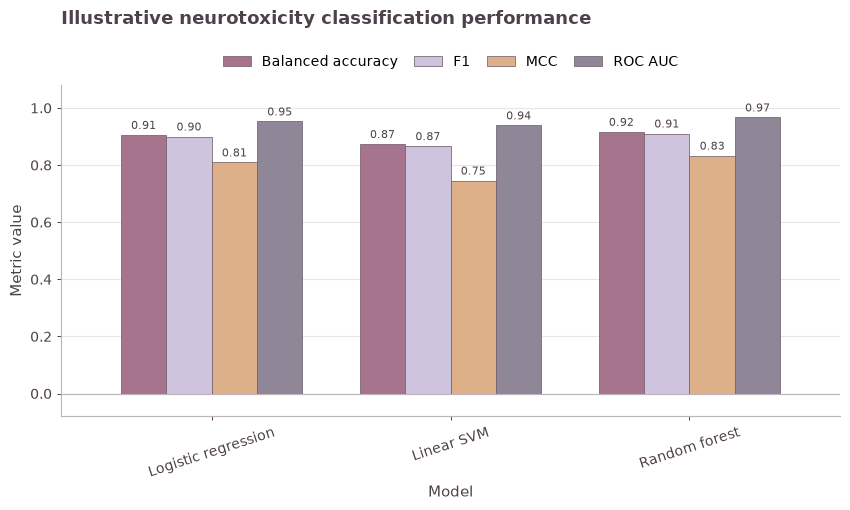

In [17]:
test_metrics = metrics.loc[metrics["partition"].eq("test")].copy()
plot_metrics = test_metrics.set_index("model")[
    ["balanced_accuracy", "f1", "mcc", "roc_auc"]
]
plot_metrics.index = plot_metrics.index.map({
    "logistic_regression": "Logistic regression",
    "linear_svm": "Linear SVM",
    "random_forest": "Random forest",
})

fig, ax = plt.subplots(figsize=(8.6, 5.2))
plot_metrics.plot(
    kind="bar",
    ax=ax,
    color=[METRIC_COLORS[column] for column in plot_metrics.columns],
    edgecolor=EDGE_COLOR,
    linewidth=0.55,
    width=0.76,
)
for container in ax.containers:
    labels = [
        f"{bar.get_height():.2f}" if np.isfinite(bar.get_height()) else ""
        for bar in container
    ]
    ax.bar_label(container, labels=labels, padding=2.5, color=TEXT_COLOR, fontsize=7.7)
ax.axhline(0, color="#BDB3BC", linewidth=0.8, label="_nolegend_")
ax.set_ylim(-0.08, 1.08)
ax.set_xlabel("Model")
ax.set_ylabel("Metric value")
ax.set_title("Illustrative neurotoxicity classification performance", loc="left", pad=44)
ax.tick_params(axis="x", rotation=18)
ax.legend(
    labels=["Balanced accuracy", "F1", "MCC", "ROC AUC"],
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=4,
    columnspacing=1.2,
)
style_axes(ax)
fig.tight_layout()
save_figure(fig, "02_test_model_performance")
plt.show()

## 10. Test-set confusion matrices


Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/02_neurotoxicity_classification/figures/confusion_matrix_logistic_regression.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/02_neurotoxicity_classification/figures/confusion_matrix_logistic_regression.pdf


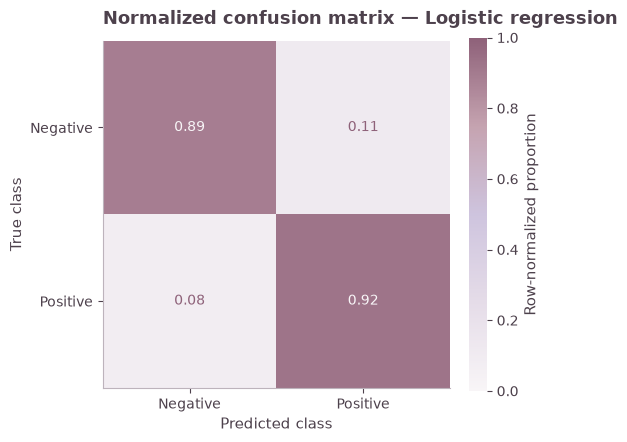

Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/02_neurotoxicity_classification/figures/confusion_matrix_linear_svm.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/02_neurotoxicity_classification/figures/confusion_matrix_linear_svm.pdf


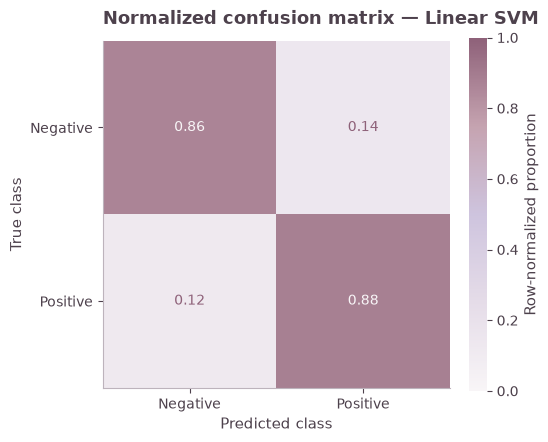

Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/02_neurotoxicity_classification/figures/confusion_matrix_random_forest.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/02_neurotoxicity_classification/figures/confusion_matrix_random_forest.pdf


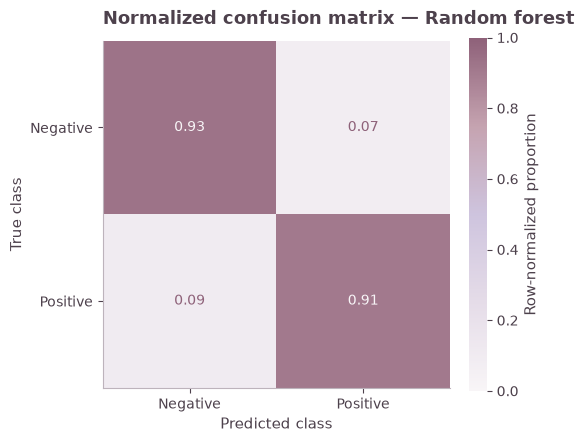

In [18]:
model_display_names = {
    "logistic_regression": "Logistic regression",
    "linear_svm": "Linear SVM",
    "random_forest": "Random forest",
}

for model_name, model in models.items():
    pred = prediction_outputs[(model_name, "test")]["prediction"].to_numpy()

    cm = confusion_matrix(
        y_test,
        pred,
        labels=[0, 1],
        normalize="true",
    )

    fig, ax = plt.subplots(figsize=(5.5, 4.9))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"],
    )
    disp.plot(
        ax=ax,
        values_format=".2f",
        cmap=MAOMAO_CMAP,
        colorbar=False,
    )
    disp.im_.set_clim(0, 1)
    ax.grid(False)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(
        f"Normalized confusion matrix — {model_display_names[model_name]}",
        loc="left",
        pad=12,
    )
    cbar = fig.colorbar(disp.im_, ax=ax, fraction=0.046, pad=0.05)
    cbar.set_label("Row-normalized proportion", color=TEXT_COLOR)
    cbar.outline.set_visible(False)
    fig.tight_layout()

    save_figure(fig, f"confusion_matrix_{model_name}")
    plt.show()

## 11. Record model and analysis metadata


In [19]:
model_parameters = pd.DataFrame([
    {
        "model": "logistic_regression",
        "scaling": "StandardScaler",
        "class_weight": "balanced",
        "main_parameters": "max_iter=3000",
    },
    {
        "model": "linear_svm",
        "scaling": "StandardScaler",
        "class_weight": "balanced",
        "main_parameters": "LinearSVC defaults otherwise",
    },
    {
        "model": "random_forest",
        "scaling": "none",
        "class_weight": "balanced",
        "main_parameters": "n_estimators=300",
    },
])

analysis_metadata = pd.DataFrame([{
    "endpoint": ENDPOINT,
    "representation": representation_name,
    "feature_contract": feature_contract,
    "n_features": len(feature_columns),
    "split_strategy": SPLIT_STRATEGY,
    "seed": seed_dir.name,
    "fold": fold_dir.name,
    "hyperparameter_optimization": False,
    "homology_aware_interpretation": False,
    "random_state_for_models": RANDOM_STATE,
}])

display(model_parameters)
display(analysis_metadata)

model_parameters.to_csv(TABLE_DIR / "model_parameters.tsv", sep="\t", index=False)
analysis_metadata.to_csv(TABLE_DIR / "analysis_metadata.tsv", sep="\t", index=False)


,model,scaling,class_weight,main_parameters
0,logistic_regression,StandardScaler,balanced,max_iter=3000
1,linear_svm,StandardScaler,balanced,LinearSVC defaults otherwise
2,random_forest,none,balanced,n_estimators=300


,endpoint,representation,feature_contract,n_features,split_strategy,seed,fold,hyperparameter_optimization,homology_aware_interpretation,random_state_for_models
0,neurotoxic,esm2_t6_8M_UR50D,p_<integer>,320,stratified_kfold,seed_113,fold_00,False,False,42
